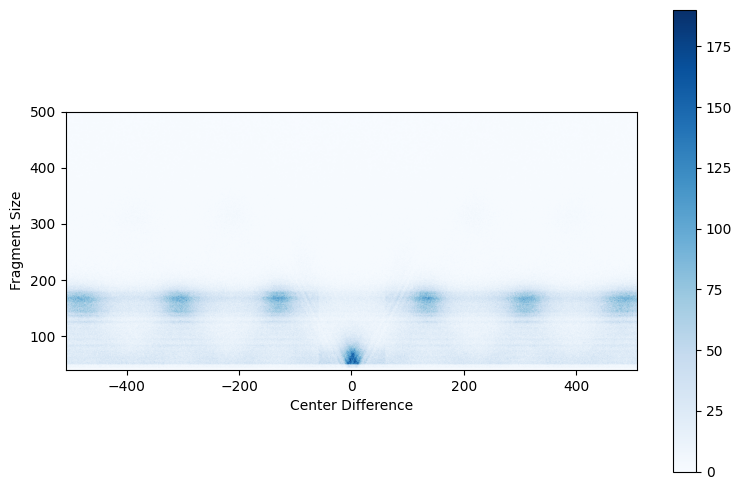

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

freq = defaultdict(int)
with open('mapped.bed/mapped.bed') as file:
    for line in file:
        cols = line.strip().split('\t')
        center1 = (int(cols[2]) + int(cols[3])) // 2
        center2 = (int(cols[8]) + int(cols[9])) // 2
        diff = center2 - center1
        size = int(cols[9]) - int(cols[8])
        freq[(diff, size)] += 1

x_vals = []
y_vals = []
counts = []

for (x, y), count in freq.items():
    x_vals.append(x)
    y_vals.append(y)
    counts.append(count)

x_unique = sorted(set(x_vals))
y_unique = sorted(set(y_vals))

x_idx = {val: idx for idx, val in enumerate(x_unique)}
y_idx = {val: idx for idx, val in enumerate(y_unique)}

grid = np.zeros((len(y_unique), len(x_unique)))

for x, y, count in zip(x_vals, y_vals, counts):
    if x in x_idx and y in y_idx:
        grid[y_idx[y], x_idx[x]] = count

plt.figure(figsize=(8, 5))
plt.imshow(grid, cmap='Blues', origin='lower', extent=[min(x_unique), max(x_unique), min(y_unique), max(y_unique)])
plt.colorbar()
plt.xlabel('Center Difference')
plt.ylabel('Fragment Size')
plt.tight_layout()
plt.show()